# AP 155 Lab Exercise
---
## Exercise 2: Numbers, Subtractive Cancellation

_Instructions_: 
- **Report figure:** Two Figures (see *Problem 2: Rewriting functions...*) - Plot f(x) vs. x using the manual evaluation (the one with catastrophic cancellation) vs. the "better function". In each figure, show the area where the catastrophic cancellation occurs. There are two functions discussed in the exercise, hence two figures (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)
- **Report discussion:** Two Questions: 
    - (See Problem 1) Why do the "bad" and "good" formulas of the roots give out the values they do (what makes "good" good)? What led to the difference between the obtained values?
    - (See Problem 2) In each of the two functions discussed, for which values of x does the catastrophic cancellation occur (include here what the expected values were)? How were the catastrophic cancellations remedied? 
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Domingo, Judiele Fatima P.
- _Student No._: 2023-05167
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure
![Problem 2 Part 1](Subtractive_Cancellation_Problem2_Part1.png)

**Figure 1:** Comparison of manually evaluated and rewritten function using algebraic conjugate

The red broken line represents the manually evaluated function while the solid blue line represents the function rewritten to avoid cancellation via conjugate. The highlighted yellow region (x>1e15) marks the cancellation region where the manually evaluated function breaks down. 

![Problem 2 Part 1](Subtractive_Cancellation_Problem2_Part2.png)

**Figure 2:** Comparison of manually evaluated and rewritten function using special function *'np.expm1( )'*. 

The red broken line represents the manually evaluated function while the solid blue line represents the function rewritten to avoid cancellation via np.expm1(). The highlighted yellow region (x<1e-13) marks the cancellation region where the manually evaluated function breaks down.
### Report discussion

In Problem 1, the quadratic equation fails when b is much larger than ac. This results in subtracting the value b with a value identical to it that results to a loss of precision since fewer significant digits are kept. This was resolved using the given identity in Gezerlis which avoids subtraction entirely.

For problem 2 part 1, the cancellation happens at very large values of x specifically, x>1e15,. In this region, the square root becomes approximately equal to x. When evaluated directly, it causes a loss in precision similar to problem 1 causing the function to drastically drop to 0.0. The cancellation was resolved by multiplying the algebraic conjugate to skip the subtraction entirely.

For problem 2 part 2, the cancellation happens at very small values of x (near zero) specifically, x<1e-13. In this region the manually evaluated function oscillates before dropping to 0.0. The oscillation is caused by the computer jumping between rounding $e^x$ to 1 and slightly above 1. It permanently becomes 0.0 from x<1e-16 as the computer permanently rounds it up to 1. This cancellation was resolved using a special function 'np.expm1()' which computes $e^x-1$ by Taylor series expansion. 
### Other comments
- N/A


## Section 2 (Problems and Code)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Quadratic Equation (Gezerlis Problem 2.6)
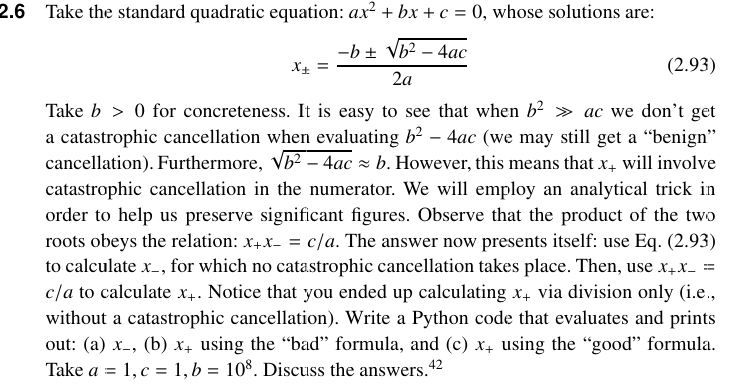

In [2]:
"""
1.  x-: evaluate eqn 2.93 using '-' operator
2.  x+ bad: evaluate from eqn 2.93 directly using '+' operator
3. x+ good:
    use the given relation:
    x+*x-=c/a
    such that x+ = c/(a*x-)
"""

#coefficients
a = 1
c = 1
b = 10**8
#function to get x-, performs quadratic equation with subtraction
def get_x_minus(a,b,c):
    numerator = -b - np.sqrt(b**2-4*a*c)
    denominator = 2*a
    x_minus = numerator/denominator
    return x_minus
x_minus=get_x_minus(a,b,c)
print('x_minus = ',x_minus)

x_minus =  -100000000.0


In [3]:

#gets x+ directly from quadratic formula
def get_x_plus_bad(a,b,c):
    numerator = -b + np.sqrt(b**2-4*a*c) #results -b + b; cause of catastrophic cancellation
    denominator = 2*a
    x_plus_bad = numerator/denominator
    return x_plus_bad
#gets x+ from relation, division multiplication used
def get_x_plus_good(a,b,c):
    denominator = a*x_minus 
    x_plus_good = c/denominator #avoids subtraction
    return x_plus_good
x_plus_bad = get_x_plus_bad(a,b,c)
x_plus_good = get_x_plus_good(a,b,c)
print('x_plus the bad way = ',x_plus_bad)
print('x_plus the good way = ', x_plus_good)

x_plus the bad way =  -7.450580596923828e-09
x_plus the good way =  -1e-08


#### Problem 1 code summary

The code aims to solve the roots of the equation first by simply plugging in, and secondly by using a given relation. It demonstrates the precision limitations of computers and shows the need for analytical solutions. 

---


### Problem 2: Rewriting Functions to avoid subtractive cancellation

### Part 1: $ f(x) = \sqrt{x^2 + x} - x $

Consider the function 
$$ f(x) = \sqrt{x^2 + x} - x $$

- For which values of x does the catastrophic cancellation occur? 
- How can we rewrite the function to avoid catastrophic cancellation? 
- [FIGURE] Plot f(x) vs. x using the manual evaluation vs. the rewritten function. In the figure, show the area where the catastrophic cancellation occurs. (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)

In [4]:
"""
1.create function direct substitution
2. create rewritten function
3. plot both functions
"""
# through manual evaluation
def func1_manual(x):
    radicand = x**2 + x
    squareroot = np.sqrt(radicand)
    f1_manual = squareroot-x #catastrophic cancellation arises in higher powers of 10
    return f1_manual 

#rewritten using algebraic conjugate
def func1_rewritten(x): 
    radicand = x**2 +x
    denominator = np.sqrt(radicand)+x # avoids subtraction
    f1_rewritten = x/denominator # denom cannot be 0 hence, log scale
    return f1_rewritten


In [5]:
#plotting

def plotting_manual_vs_rewritten(x,ys1,ys2,title,lower,upper):
    plt.figure(figsize=(9, 5))
    plt.xscale('log')
    plt.xlabel('x (log scale)')
    plt.xlim(x.min(), x.max())
    plt.ylabel('f(x)')
    plt.title(title)
    plt.plot(x, ys1, 'b-', label='rewritten function', linewidth=3)
    plt.plot(x, ys2, 'r--', label='manual function', linewidth=1.5)
    #highlights cancellation area
    plt.axvspan(lower,upper, color='yellow', alpha=0.25, label='Cancellation Region')
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend()
    plt.show()

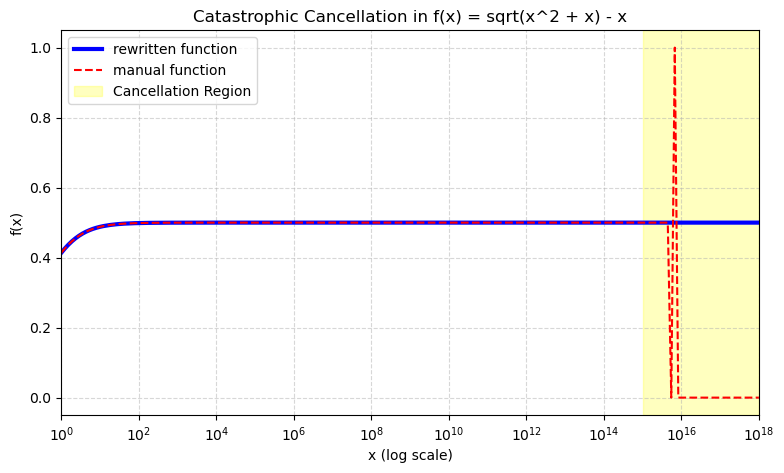

In [6]:
#calling functions
x = np.logspace(0,18,num=200,base=10)
y_rewritten=func1_rewritten(x)
y_manual = func1_manual(x)
plotting_manual_vs_rewritten(x,y_rewritten,y_manual,lower=1e15,upper=1e18,title='Catastrophic Cancellation in f(x) = sqrt(x^2 + x) - x' )

#### Part 2: $ f(x) = \frac{e^x - 1}{x}$

Consider the function 
$$ f(x) = \frac{e^x - 1}{x}$$

- For which values of x does the catastrophic cancellation occur? 
- How can we resolve the catastrophic cancellation? 
- [FIGURE] Plot the f(x) vs. x using the manual evaluation vs. the numpy special function. In the figure, show the area where the catastrophic cancellation occurs. (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)



In [7]:
"""
1. create manual function
2. create rewritten function
3. plot both functions in one graph
"""
#manual evaluation
def func2_manual(x):
    numerator = np.exp(x)-1 #fails when e^x is approx 1; x is near 0
    func2_manual = numerator/x
    return func2_manual
#rewritten
def func2_rewritten(x):
    return np.expm1(x)/x 
#taken from https://numpy.org/doc/stable/reference/generated/numpy.expm1.html

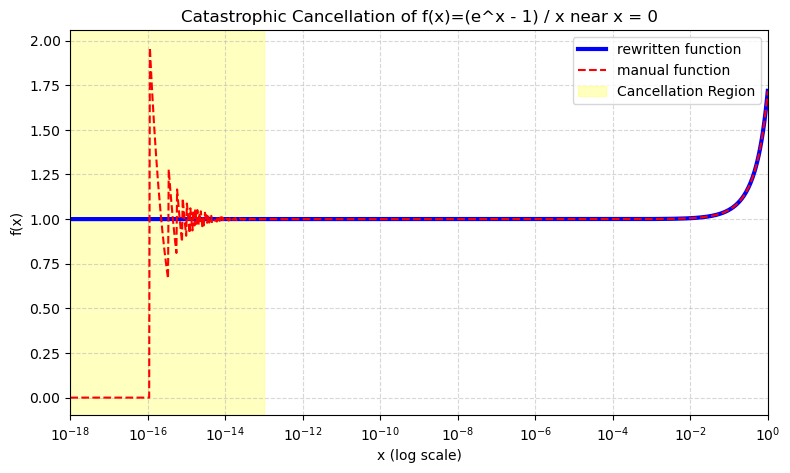

In [8]:
#calling functions
x2 = np.logspace(-18,0,num=1000,base=10)
y2_manual = func2_manual(x2)
y2_rewritten = func2_rewritten(x2)
plotting_manual_vs_rewritten(x2,y2_rewritten,y2_manual,title='Catastrophic Cancellation of f(x)=(e^x - 1) / x near x = 0', lower=1e-18,upper=1e-13)

#### Problem 2 code summary
Problem 2 visually represents catastrophic cancellation. Part 1 resolves the cancellation through algebraic manipulation while part 2 resolves it through taylor expansion via the np.expm1() function. For part 1, the error arises at large powers of 10 while in part 2 it occurs in very small powers of 10.

---

## Section 3 (Notes)

### Floating-point representation
Python uses 64-bit float by default for any number you type in with a decimal point. Different floating point precision can be used at a lower level, which we can go around by using [Numpy dtypes](https://numpy.org/doc/stable/reference/arrays.dtypes.html). 

Useful links:
* [(Goldberg, 1991) *What every computer scientist should know about floating-point arithmetic*](https://dl.acm.org/doi/10.1145/103162.103163)
* [Wikipedia - Floating-point arithmetic](https://en.wikipedia.org/wiki/Floating-point_arithmetic)
* [Data types - NumPy](https://numpy.org/doc/stable/user/basics.types.html)
* [decimal — Decimal fixed-point and floating-point arithmetic](https://docs.python.org/3/library/decimal.html)
* [fractions — Rational numbers](https://docs.python.org/3/library/fractions.html)

In [9]:
import matplotlib.pyplot as plt
import numpy as np

from decimal import Decimal
from fractions import Fraction

# Classic floating point quirks example
print(0.1 + 0.2)

# How about increasing precision?
print(np.float128(0.1) + np.float128(0.2))

# How bad is decreasing precision?
print(np.float16(0.1) + np.float16(0.2))

# Closest we could get to fixed-point arithmetic: decimal
print(Decimal(0.1) + Decimal(0.2))

# How about using an explicit Fraction object type?
print(float(Fraction(1, 10) + Fraction(1, 5)))

0.30000000000000004
0.30000000000000001665
0.2998
0.3000000000000000166533453694
0.3
